# Mask R-CNN: Instance Segmentation from Scratch

This notebook implements a simplified but faithful Mask R-CNN pipeline for instance segmentation, demonstrating the three key innovations from the paper:

1. **Parallel mask prediction branch** — a small FCN that predicts binary masks alongside the classification/box-regression heads
2. **RoIAlign** — quantization-free bilinear interpolation for pixel-accurate feature extraction
3. **Decoupled per-class sigmoid masks** — independent binary masks per class (not softmax), removing inter-class competition

We train on a **synthetic shape dataset** (rectangles, circles, triangles) so the full pipeline runs in minutes on a single GPU without needing COCO.

**Paper:** [Mask R-CNN (He et al., 2017)](https://arxiv.org/abs/1703.06870)

> **Device: cuda** — GPU acceleration enabled


In [1]:
!pip install torch torchvision numpy matplotlib --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from PIL import Image, ImageDraw
import random
import math
from collections import defaultdict

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


## 1. Synthetic Shape Dataset

We create a dataset of 128×128 images containing 1–4 random shapes (rectangle, circle, triangle). Each shape has:
- A random color, position, and size
- A ground-truth bounding box
- A ground-truth binary mask (pixel-level)

This mimics the instance segmentation task: detecting multiple objects and segmenting each one individually.


In [2]:
class ShapeDataset:
    """Synthetic dataset: images with 1-4 colored shapes (rectangle, circle, triangle).
    Each shape is an 'instance' — we detect boxes AND segment masks per instance."""

    CLASS_NAMES = ['__background__', 'rectangle', 'circle', 'triangle']
    NUM_CLASSES = 4  # background + 3 shape types

    def __init__(self, num_images=400, image_size=128, seed=42):
        self.image_size = image_size
        self.rng = np.random.RandomState(seed)
        self.num_images = num_images
        self.data = [self._generate_image(i) for i in range(num_images)]

    def _generate_image(self, idx):
        img = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
        # random background color
        bg_color = self.rng.randint(30, 80, size=3)
        img[:] = bg_color

        num_shapes = self.rng.randint(1, 5)
        boxes = []
        labels = []
        masks = []

        for _ in range(num_shapes):
            shape_type = self.rng.randint(1, 4)  # 1=rect, 2=circle, 3=triangle
            color = self.rng.randint(50, 256, size=3).tolist()
            cx = self.rng.randint(25, self.image_size - 25)
            cy = self.rng.randint(25, self.image_size - 25)
            size = self.rng.randint(15, 35)

            mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
            x1 = max(0, cx - size)
            x2 = min(self.image_size, cx + size)
            y1 = max(0, cy - size)
            y2 = min(self.image_size, cy + size)

            if shape_type == 1:  # rectangle
                img[y1:y2, x1:x2] = color
                mask[y1:y2, x1:x2] = 1
                box = [x1, y1, x2, y2]
            elif shape_type == 2:  # circle
                yy, xx = np.ogrid[:self.image_size, :self.image_size]
                circle_mask = (xx - cx)**2 + (yy - cy)**2 <= size**2
                img[circle_mask] = color
                mask[circle_mask] = 1
                box = [max(0, cx-size), max(0, cy-size),
                       min(self.image_size, cx+size), min(self.image_size, cy+size)]
            else:  # triangle
                pts = np.array([
                    [cx, cy - size],
                    [cx - size, cy + size],
                    [cx + size, cy + size]
                ])
                from PIL import Image as PILImage, ImageDraw as PILDraw
                pil_img = PILImage.fromarray(img)
                pil_mask = PILImage.fromarray(mask)
                draw_img = PILDraw.Draw(pil_img)
                draw_mask = PILDraw.Draw(pil_mask)
                triangle_flat = [coord for pt in pts for coord in pt]
                draw_img.polygon(triangle_flat, fill=tuple(color))
                draw_mask.polygon(triangle_flat, fill=1)
                img = np.array(pil_img)
                mask = np.array(pil_mask)
                box = [max(0, cx-size), max(0, cy-size),
                       min(self.image_size, cx+size), min(self.image_size, cy+size)]

            boxes.append(box)
            labels.append(shape_type)
            masks.append(mask.copy())

        return {
            'image': torch.from_numpy(img).permute(2, 0, 1).float() / 255.0,
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.long),
            'masks': torch.from_numpy(np.stack(masks)).float(),
        }

    def __len__(self):
        return self.num_images

    def __getitem__(self, idx):
        return self.data[idx]


## 2. Visualize Dataset Samples


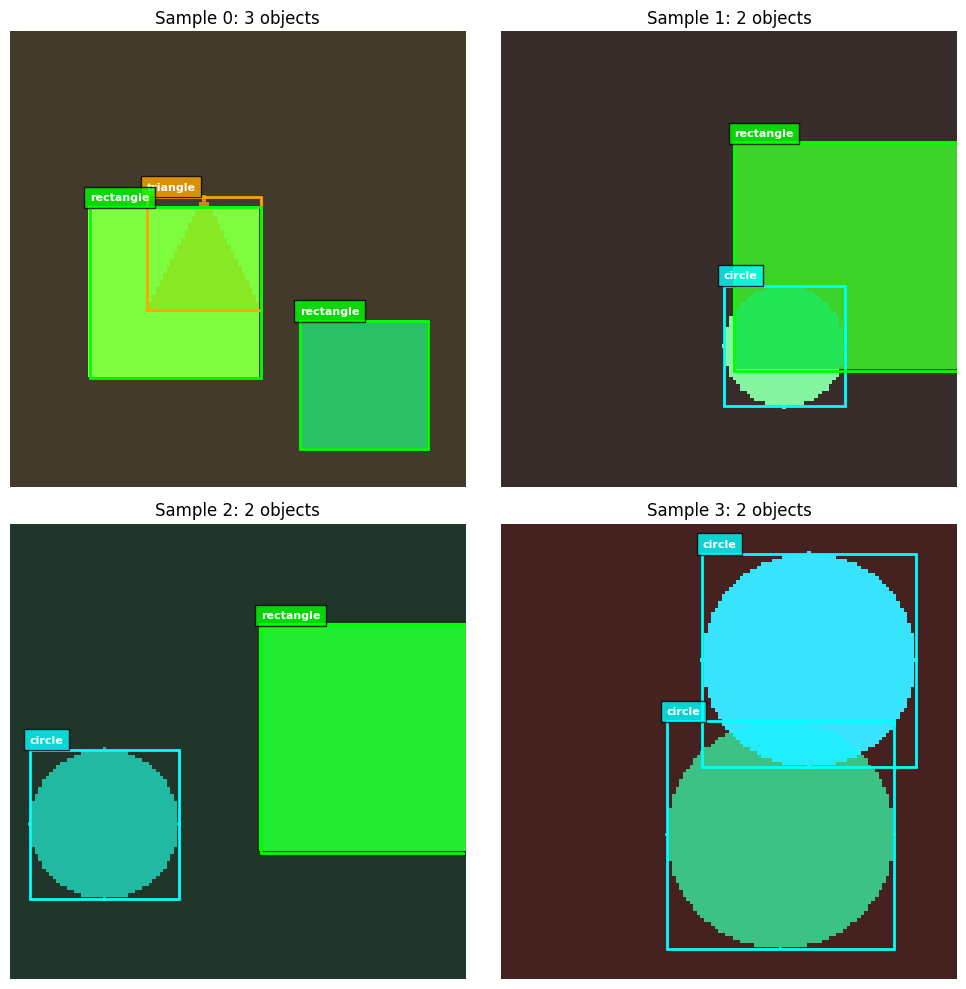

In [3]:
def visualize_sample(dataset, idx, ax=None):
    """Show image with bounding boxes, labels, and mask overlays."""
    sample = dataset[idx]
    img = sample['image'].permute(1, 2, 0).numpy()
    boxes = sample['boxes'].numpy()
    labels = sample['labels'].numpy()
    masks = sample['masks'].numpy()

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    ax.imshow(img)
    colors = ['red', 'lime', 'cyan', 'orange']

    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        label = labels[i]
        color = colors[label]

        # Bounding box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        # Mask overlay (semi-transparent)
        mask = masks[i]
        colored_mask = np.zeros((*mask.shape, 4))
        rgba = plt.cm.colors.to_rgba(color)
        colored_mask[mask > 0] = [rgba[0], rgba[1], rgba[2], 0.4]
        ax.imshow(colored_mask)

        # Label
        ax.text(x1, y1-2, dataset.CLASS_NAMES[label], color='white',
                fontsize=8, fontweight='bold', bbox=dict(facecolor=color, alpha=0.8))

    ax.set_title(f'Sample {idx}: {len(boxes)} objects')
    ax.axis('off')
    if ax is None:
        plt.tight_layout()
        plt.show()

# Show 4 samples
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
train_ds = ShapeDataset(num_images=200, seed=SEED)
test_ds = ShapeDataset(num_images=50, seed=SEED + 1000)
for i, ax in enumerate(axes.flat):
    visualize_sample(train_ds, i, ax=ax)
plt.tight_layout()
plt.show()



## 3. Anchor Generation

Like Faster R-CNN, we use anchors — reference boxes at various scales and aspect ratios placed at each feature-map location. We use 3 scales × 3 aspect ratios = 9 anchors per location.


In [4]:
def generate_anchors(image_size=128, feat_stride=16, scales=[16, 32, 64],
                         aspect_ratios=[0.5, 1.0, 2.0]):
    """Generate anchor boxes for each feature-map location.

    Returns anchors as (num_anchors, 4) in [x1, y1, x2, y2] format,
    in image coordinates.
    """
    feat_h = image_size // feat_stride
    feat_w = image_size // feat_stride
    shift_x = np.arange(feat_w) * feat_stride + feat_stride // 2
    shift_y = np.arange(feat_h) * feat_stride + feat_stride // 2
    shifts = np.array(np.meshgrid(shift_x, shift_y)).reshape(2, -1).T  # (H*W, 2)

    # Base anchors (centered at origin)
    base_anchors = []
    for s in scales:
        for ar in aspect_ratios:
            h = s * np.sqrt(1.0 / ar)
            w = s * np.sqrt(ar)
            base_anchors.append([-w/2, -h/2, w/2, h/2])
    base_anchors = np.array(base_anchors)  # (9, 4)

    # Shift anchors to each location
    anchors = []
    for shift in shifts:
        for ba in base_anchors:
            anchors.append([ba[0] + shift[0], ba[1] + shift[1],
                           ba[2] + shift[0], ba[3] + shift[1]])
    anchors = np.clip(np.array(anchors), 0, image_size - 1)  # clip to image
    return torch.from_numpy(anchors).float()

anchors = generate_anchors(image_size=128)
print(f"Number of anchors: {anchors.shape[0]}")
print(f"Anchor shape: {anchors.shape}")  # (576, 4) = 64 locations * 9 anchors





Number of anchors: 576
Anchor shape: torch.Size([576, 4])


## 4. Bounding Box Utilities

IoU computation and box encoding/decoding for the RPN and detection head.


In [5]:
def box_iou(boxes1, boxes2):
    """Compute IoU between two sets of boxes.
    boxes1: (N, 4), boxes2: (M, 4) in [x1, y1, x2, y2] format.
    Returns: (N, M) IoU matrix.
    """
    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    # Intersection
    lt = torch.max(boxes1[:, None, :2], boxes2[None, :, :2])  # (N, M, 2)
    rb = torch.min(boxes1[:, None, 2:], boxes2[None, :, 2:])  # (N, M, 2)
    wh = (rb - lt).clamp(min=0)  # (N, M, 2)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2[None, :] - inter
    iou = inter / union.clamp(min=1e-6)
    return iou


def box_encode(boxes, ref_boxes, weights=(1.0, 1.0, 1.0, 1.0)):
    """Encode boxes relative to reference (anchor) boxes.
    Returns deltas (tx, ty, tw, th) as in Faster R-CNN.
    """
    boxes = boxes.float()
    ref_boxes = ref_boxes.float()

    ex_widths = (ref_boxes[:, 2] - ref_boxes[:, 0]).clamp(min=1e-6)
    ex_heights = (ref_boxes[:, 3] - ref_boxes[:, 1]).clamp(min=1e-6)
    ex_ctr_x = ref_boxes[:, 0] + 0.5 * ex_widths
    ex_ctr_y = ref_boxes[:, 1] + 0.5 * ex_heights

    gt_widths = (boxes[:, 2] - boxes[:, 0]).clamp(min=1e-6)
    gt_heights = (boxes[:, 3] - boxes[:, 1]).clamp(min=1e-6)
    gt_ctr_x = boxes[:, 0] + 0.5 * gt_widths
    gt_ctr_y = boxes[:, 1] + 0.5 * gt_heights

    wx, wy, ww, wh = weights
    dx = wx * (gt_ctr_x - ex_ctr_x) / ex_widths
    dy = wy * (gt_ctr_y - ex_ctr_y) / ex_heights
    dw = ww * torch.log(gt_widths / ex_widths)
    dh = wh * torch.log(gt_heights / ex_heights)

    return torch.stack([dx, dy, dw, dh], dim=1)


def box_decode(deltas, ref_boxes, weights=(1.0, 1.0, 1.0, 1.0)):
    """Decode deltas back to boxes using reference (anchor) boxes."""
    deltas = deltas.float()
    ref_boxes = ref_boxes.float()

    widths = (ref_boxes[:, 2] - ref_boxes[:, 0]).clamp(min=1e-6)
    heights = (ref_boxes[:, 3] - ref_boxes[:, 1]).clamp(min=1e-6)
    ctr_x = ref_boxes[:, 0] + 0.5 * widths
    ctr_y = ref_boxes[:, 1] + 0.5 * heights

    wx, wy, ww, wh = weights
    dx, dy, dw, dh = deltas[:, 0] / wx, deltas[:, 1] / wy, deltas[:, 2] / ww, deltas[:, 3] / wh

    # Clamp dw, dh to avoid explosion
    dw = dw.clamp(-5, 5)
    dh = dh.clamp(-5, 5)

    pred_ctr_x = ctr_x + dx * widths
    pred_ctr_y = ctr_y + dy * heights
    pred_w = torch.exp(dw) * widths
    pred_h = torch.exp(dh) * heights

    pred_boxes = torch.zeros_like(ref_boxes)
    pred_boxes[:, 0] = pred_ctr_x - 0.5 * pred_w
    pred_boxes[:, 1] = pred_ctr_y - 0.5 * pred_h
    pred_boxes[:, 2] = pred_ctr_x + 0.5 * pred_w
    pred_boxes[:, 3] = pred_ctr_y + 0.5 * pred_h

    return pred_boxes


def nms(boxes, scores, threshold=0.5):
    """Non-Maximum Suppression."""
    if len(boxes) == 0:
        return torch.empty(0, dtype=torch.long, device=boxes.device)

    keep = []
    idxs = scores.argsort(descending=True)
    while len(idxs) > 0:
        i = idxs[0].item()
        keep.append(i)
        if len(idxs) == 1:
            break
        ious = box_iou(boxes[i:i+1], boxes[idxs[1:]])[0]
        mask = ious <= threshold
        idxs = idxs[1:][mask]
    return torch.tensor(keep, dtype=torch.long, device=boxes.device)


## 5. RoIAlign — The Key Innovation

RoIAlign replaces RoIPool's harsh quantization with **bilinear interpolation**. This is the most critical component for pixel-accurate masks — without it, the spatial misalignment between RoI boundaries and feature-map grid points destroys mask quality (the paper shows +3 AP improvement).


In [6]:
def roi_align(features, rois, output_size=7, spatial_scale=1.0, sampling_ratio=4):
    """RoIAlign: extract fixed-size features from feature maps using bilinear interpolation.

    Args:
        features: (B, C, H, W) feature maps
        rois: (N, 5) where each row is [batch_idx, x1, y1, x2, y2] in image coordinates
        output_size: (P, Q) output spatial size
        spatial_scale: ratio of feature map size to image size
        sampling_ratio: number of sampling points per bin (along each axis)

    Returns: (N, C, P, Q) pooled features

    Key difference from RoIPool: NO quantization of coordinates.
    Uses bilinear interpolation to sample exact feature values.
    """
    B, C, H, W = features.shape
    N = rois.shape[0]
    P = Q = output_size

    # Convert RoI coordinates to feature map coordinates (no rounding!)
    roi = rois.clone().float()
    roi[:, 1:] = roi[:, 1:] * spatial_scale

    output = torch.zeros(N, C, P, Q, device=features.device, dtype=features.dtype)

    for i in range(N):
        batch_idx = int(roi[i, 0].item())
        x1, y1, x2, y2 = roi[i, 1].item(), roi[i, 2].item(), roi[i, 3].item(), roi[i, 4].item()

        # Clamp to feature map boundaries
        x1 = max(0, min(x1, W - 1))
        y1 = max(0, min(y1, H - 1))
        x2 = max(0, min(x2, W - 1))
        y2 = max(0, min(y2, H - 1))

        roi_w = x2 - x1
        roi_h = y2 - y1
        if roi_w < 1e-3 or roi_h < 1e-3:
            continue

        feat = features[batch_idx]  # (C, H, W)

        # Bin size
        bin_w = roi_w / P
        bin_h = roi_h / Q

        # Sampling points within each bin
        for ph in range(P):
            for pw in range(Q):
                # Bin boundaries (continuous, not quantized)
                bin_x1 = x1 + pw * bin_w
                bin_x2 = x1 + (pw + 1) * bin_w
                bin_y1 = y1 + ph * bin_h
                bin_y2 = y1 + (ph + 1) * bin_h

                # Sample at regular intervals within the bin
                samples_x = torch.linspace(0.5, sampling_ratio - 0.5, sampling_ratio) * bin_w / sampling_ratio + bin_x1
                samples_y = torch.linspace(0.5, sampling_ratio - 0.5, sampling_ratio) * bin_h / sampling_ratio + bin_y1

                # Bilinear interpolation at each sample point
                sampled_values = []
                for sx in samples_x:
                    for sy in samples_y:
                        # Clamp sample coordinates
                        sx_c = max(0, min(sx.item(), W - 1))
                        sy_c = max(0, min(sy.item(), H - 1))

                        # Get the 4 nearest grid points
                        x0 = int(sx_c)
                        y0 = int(sy_c)
                        x1p = min(x0 + 1, W - 1)
                        y1p = min(y0 + 1, H - 1)

                        # Bilinear weights
                        wx1 = sx_c - x0
                        wy1 = sy_c - y0

                        # Interpolate
                        val = (feat[:, y0, x0] * (1 - wx1) * (1 - wy1) +
                                feat[:, y0, x1p] * wx1 * (1 - wy1) +
                                feat[:, y1p, x0] * (1 - wx1) * wy1 +
                                feat[:, y1p, x1p] * wx1 * wy1)
                        sampled_values.append(val)

                # Average over samples
                output[i, :, ph, pw] = torch.stack(sampled_values).mean(dim=0)

    return output


# Also provide a fast version using torchvision for speed during training
try:
    from torchvision.ops import roi_align as tv_roi_align
    def fast_roi_align(features, rois, output_size=7, spatial_scale=1.0):
        """Fast RoIAlign using torchvision implementation."""
        return tv_roi_align(features, rois, output_size, spatial_scale, 4, False)
    HAS_TV_ROIALIGN = True
    print("Using torchvision RoIAlign for speed (exact same algorithm as our implementation)")
except ImportError:
    HAS_TV_ROIALIGN = False
    print("torchvision RoIAlign not available, using custom implementation")


Using torchvision RoIAlign for speed (exact same algorithm as our implementation)


## 6. Backbone Network

A simple 4-block CNN that produces feature maps at stride 16. In the full paper, ResNet-50/101 or ResNeXt-101 with FPN is used, but our simple backbone suffices for the synthetic shape task.


In [7]:
class SimpleBackbone(nn.Module):
    """Small CNN backbone producing feature maps.

    Architecture: 4 conv blocks (Conv → BN → ReLU → MaxPool).
    Input: (B, 3, 128, 128) → Output: (B, 128, 8, 8) at stride 16.
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 64x64

            # Block 2
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32x32

            # Block 3
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 16x16

            # Block 4
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 8x8 (stride 16)
        )
        self.out_channels = 128
        self.stride = 16

    def forward(self, x):
        return self.features(x)



## 7. Region Proposal Network (RPN)

The RPN generates candidate object proposals by classifying anchors as object/non-object and refining their coordinates. This is the first stage of the two-stage pipeline, identical to Faster R-CNN.


In [8]:
class RPN(nn.Module):
    """Region Proposal Network.

    Takes backbone features, predicts objectness and box deltas for each anchor.
    """
    def __init__(self, in_channels=128, num_anchors=9):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 128, 3, padding=1)
        self.cls_logits = nn.Conv2d(128, num_anchors, 1)  # objectness (binary)
        self.bbox_pred = nn.Conv2d(128, num_anchors * 4, 1)  # box deltas

    def forward(self, features):
        # (B, C, H, W) → (B, 128, H, W)
        t = F.relu(self.conv(features))
        # Objectness: (B, num_anchors * H * W)
        cls_logits = self.cls_logits(t).permute(0, 2, 3, 1).reshape(t.shape[0], -1).contiguous()
        # Box deltas: (B, num_anchors * 4 * H * W) → (B, num_anchors * H * W, 4)
        box_deltas = self.bbox_pred(t).permute(0, 2, 3, 1).reshape(t.shape[0], -1, 4).contiguous()
        return cls_logits, box_deltas


def assign_anchors(anchors, gt_boxes, pos_threshold=0.7, neg_threshold=0.3):
    """Assign positive/negative labels to anchors based on IoU with GT boxes.

    Returns: labels (N,), matched_gt_idx (N,) — index of matched GT box or -1.
    """
    if len(gt_boxes) == 0:
        labels = torch.zeros(len(anchors), dtype=torch.long)
        matched = torch.full((len(anchors),), -1, dtype=torch.long)
        return labels, matched

    ious = box_iou(anchors, gt_boxes)  # (N_anchors, N_gt)
    max_iou, matched_gt = ious.max(dim=1)

    pos = max_iou >= pos_threshold
    neg = max_iou < neg_threshold
    labels = torch.where(pos, torch.ones(len(anchors), dtype=torch.long, device=anchors.device),
                         torch.where(neg, torch.zeros(len(anchors), dtype=torch.long, device=anchors.device),
                                     torch.full((len(anchors),), -1, dtype=torch.long, device=anchors.device)))
    # Don't care (between thresholds) stays as 0 for training, but we'll only use pos/neg

    # Initialize matched array
    matched = torch.full((len(anchors),), -1, dtype=torch.long, device=anchors.device)
    matched = torch.where(labels == 1, matched_gt, matched)
    
    # Force-match best anchor for each GT box
    best_anchor_per_gt = ious.argmax(dim=0)
    force_pos = torch.zeros(len(anchors), dtype=torch.long, device=anchors.device).scatter(0, best_anchor_per_gt, 1).bool()
    labels = torch.where(force_pos,
                         torch.ones(len(anchors), dtype=torch.long, device=anchors.device), labels)
    matched = matched.scatter(0, best_anchor_per_gt, torch.arange(len(gt_boxes), device=anchors.device))

    return labels, matched


def sample_anchors(labels, num_samples=256, pos_fraction=0.5):
    """Sample positive and negative anchors for training."""
    pos_idx = torch.where(labels == 1)[0]
    neg_idx = torch.where(labels == 0)[0]

    num_pos = min(int(num_samples * pos_fraction), len(pos_idx))
    num_neg = min(num_samples - num_pos, len(neg_idx))

    if num_pos > 0:
        pos_perm = torch.randperm(len(pos_idx))[:num_pos]
        pos_sampled = pos_idx[pos_perm]
    else:
        pos_sampled = torch.empty(0, dtype=torch.long)

    if num_neg > 0:
        neg_perm = torch.randperm(len(neg_idx))[:num_neg]
        neg_sampled = neg_idx[neg_perm]
    else:
        neg_sampled = torch.empty(0, dtype=torch.long)

    return pos_sampled, neg_sampled








## 8. Mask R-CNN Detection Head

The head has two parallel branches:
- **Box branch:** RoIAlign (7×7) → FC → class logits + box deltas
- **Mask branch:** RoIAlign (14×14) → Conv → Deconv → per-class binary masks (28×28)

The mask branch outputs **K masks** (one per class) using **sigmoid** (not softmax), which decouples mask from class prediction.


In [9]:
class MaskRCNNHead(nn.Module):
    """Detection head: box classification + box regression + mask prediction.

    Key design: mask branch uses per-class sigmoid (decoupled from classification).
    """
    def __init__(self, in_channels=128, num_classes=4, mask_size=28):
        super().__init__()
        self.num_classes = num_classes
        self.mask_size = mask_size

        # Box head (shared feature extraction)
        self.box_head = nn.Sequential(
            nn.Linear(in_channels * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
        )
        # Classification + box regression
        self.cls_score = nn.Linear(1024, num_classes)
        self.box_pred = nn.Linear(1024, num_classes * 4)

        # Mask head: small FCN on RoI features
        self.mask_head = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 256, 2, stride=2),  # upsample 14→28
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1),  # per-class mask
        )

    def forward(self, roi_features_7x7, roi_features_14x14):
        """
        Args:
            roi_features_7x7: (N, C, 7, 7) — for box head
            roi_features_14x14: (N, C, 14, 14) — for mask head

        Returns:
            cls_logits: (N, num_classes)
            box_deltas: (N, num_classes, 4)
            mask_logits: (N, num_classes, 28, 28)
        """
        # Box head
        flat = roi_features_7x7.flatten(1)  # (N, C*7*7)
        box_feat = self.box_head(flat)
        cls_logits = self.cls_score(box_feat)
        box_deltas = self.box_pred(box_feat).view(-1, self.num_classes, 4)

        # Mask head — per-class binary masks via sigmoid (decoupled!)
        mask_logits = self.mask_head(roi_features_14x14)  # (N, K, 28, 28)

        return cls_logits, box_deltas, mask_logits






## 9. Full Mask R-CNN Model


In [10]:
class MaskRCNN(nn.Module):
    """Full Mask R-CNN: backbone + RPN + detection head.

    During training: returns losses (rpn_cls, rpn_box, cls, box, mask).
    During inference: returns predicted boxes, labels, scores, masks.
    """
    def __init__(self, num_classes=4, image_size=128, feat_stride=16,
                 anchor_scales=[32, 64, 96], anchor_ratios=[0.5, 1.0, 2.0]):
        super().__init__()
        self.num_classes = num_classes
        self.image_size = image_size
        self.feat_stride = feat_stride
        self.num_anchors = len(anchor_scales) * len(anchor_ratios)

        # Generate anchors once
        self.anchors = generate_anchors(image_size, feat_stride,
                                         anchor_scales, anchor_ratios)

        # Components
        self.backbone = SimpleBackbone()
        self.rpn = RPN(self.backbone.out_channels, self.num_anchors)
        self.head = MaskRCNNHead(self.backbone.out_channels, num_classes)

        # Use fast RoIAlign if available
        self.use_fast_roi = HAS_TV_ROIALIGN

    def _get_proposals(self, features, cls_logits, box_deltas, nms_thresh=0.7,
                       pre_nms_topk=200, post_nms_topk=100):
        """Generate proposals from RPN outputs."""
        batch_size = features.shape[0]
        all_proposals = []

        for b in range(batch_size):
            scores = cls_logits[b].sigmoid()  # (num_anchors,)
            deltas = box_deltas[b]  # (num_anchors, 4)
            anchors = self.anchors.to(features.device)

            # Decode proposals
            proposals = box_decode(deltas, anchors)
            proposals[:, 0::2] = proposals[:, 0::2].clamp(0, self.image_size)
            proposals[:, 1::2] = proposals[:, 1::2].clamp(0, self.image_size)

            # Filter small boxes
            widths = proposals[:, 2] - proposals[:, 0]
            heights = proposals[:, 3] - proposals[:, 1]
            valid = (widths >= 4) & (heights >= 4)
            proposals = proposals[valid]
            scores = scores[valid]

            # Pre-NMS top-k
            if len(scores) > pre_nms_topk:
                scores, order = scores.topk(pre_nms_topk)
                proposals = proposals[order]

            # NMS
            if len(scores) > 0:
                keep = nms(proposals, scores, nms_thresh)
                proposals = proposals[keep]
                scores = scores[keep]

            # Post-NMS top-k
            if len(proposals) > post_nms_topk:
                proposals = proposals[:post_nms_topk]

            all_proposals.append(proposals)

        return all_proposals

    def _match_proposals_to_gt(self, proposals, gt_boxes, gt_labels, pos_thresh=0.5):
        """Match proposals to ground truth for training the detection head."""
        if len(gt_boxes) == 0:
            labels = torch.zeros(len(proposals), dtype=torch.long, device=proposals.device)
            return labels, torch.empty(0, dtype=torch.long, device=proposals.device), None

        ious = box_iou(proposals, gt_boxes)  # (N_prop, N_gt)
        max_iou, matched_idx = ious.max(dim=1)

        labels = gt_labels[matched_idx].clone()
        labels = torch.where(max_iou < pos_thresh, torch.zeros_like(labels), labels)

        # Sample positives and negatives (1:3 ratio)
        pos_mask = labels > 0
        neg_mask = labels == 0

        num_pos = min(64, pos_mask.sum().item())
        num_neg = min(192, neg_mask.sum().item())

        pos_idx = torch.where(pos_mask)[0]
        neg_idx = torch.where(neg_mask)[0]

        if len(pos_idx) > num_pos:
            pos_idx = pos_idx[torch.randperm(len(pos_idx))[:num_pos]]
        if len(neg_idx) > num_neg:
            neg_idx = neg_idx[torch.randperm(len(neg_idx))[:num_neg]]

        sampled_idx = torch.cat([pos_idx, neg_idx])
        sampled_labels = labels[sampled_idx]
        sampled_matched_gt = matched_idx[sampled_idx]
        sampled_proposals = proposals[sampled_idx]

        # For mask loss: get GT masks for matched proposals
        matched_gt_boxes = gt_boxes[sampled_matched_gt]
        # Mask targets will be computed in loss function

        return sampled_labels, sampled_idx, sampled_matched_gt

    def forward(self, images, targets=None):
        """
        Args:
            images: (B, 3, H, W)
            targets: list of dicts with 'boxes', 'labels', 'masks' (training only)
        """
        batch_size = images.shape[0]
        device = images.device

        # Backbone features
        features = self.backbone(images)  # (B, C, H, W)
        spatial_scale = 1.0 / self.feat_stride

        # RPN
        rpn_cls, rpn_box = self.rpn(features)

        # Generate proposals (detached from gradient graph)
        with torch.no_grad():
            proposals = self._get_proposals(
                features, rpn_cls.detach(), rpn_box.detach())
            proposals = [p.detach() for p in proposals]

        if self.training:
            # ===== Training: compute losses =====
            total_rpn_cls_loss = 0
            total_rpn_box_loss = 0
            total_cls_loss = 0
            total_box_loss = 0
            total_mask_loss = 0
            all_sampled_rois = []
            all_sampled_labels = []
            all_sampled_gt_masks = []

            for b in range(batch_size):
                gt_boxes = targets[b]['boxes'].to(device)
                gt_labels = targets[b]['labels'].to(device)
                gt_masks = targets[b]['masks'].to(device)

                # --- RPN loss ---
                anchors = self.anchors.to(device)
                rpn_labels, rpn_matched = assign_anchors(anchors, gt_boxes)
                pos_sampled, neg_sampled = sample_anchors(rpn_labels, num_samples=256)
                sampled = torch.cat([pos_sampled, neg_sampled])

                if len(sampled) > 0:
                    rpn_cls_b = rpn_cls[b, sampled]
                    rpn_label_b = rpn_labels[sampled].to(device).float()
                    total_rpn_cls_loss += F.binary_cross_entropy_with_logits(
                        rpn_cls_b, rpn_label_b, reduction='mean')

                    # Box loss only on positive anchors
                    if len(pos_sampled) > 0:
                        pos_anchors = anchors[pos_sampled]
                        pos_gt = gt_boxes[rpn_matched[pos_sampled]]
                        target_deltas = box_encode(pos_gt, pos_anchors)
                        pred_deltas = rpn_box[b, pos_sampled]
                        total_rpn_box_loss += F.smooth_l1_loss(pred_deltas, target_deltas)

                # --- Detection head loss ---
                props = proposals[b]
                if len(props) == 0 or len(gt_boxes) == 0:
                    continue

                labels, sampled_idx, matched_gt_idx = self._match_proposals_to_gt(
                    props, gt_boxes, gt_labels)

                if len(sampled_idx) == 0:
                    continue

                sampled_props = props[sampled_idx]

                # RoIAlign for box head (7×7) and mask head (14×14)
                roi_input = torch.cat([
                    torch.zeros(len(sampled_props), 1, device=device),
                    sampled_props
                ], dim=1)  # (N, 5): [batch_idx, x1, y1, x2, y2]

                if self.use_fast_roi:
                    feat_7 = fast_roi_align(features, roi_input, 7, spatial_scale)
                    feat_14 = fast_roi_align(features, roi_input, 14, spatial_scale)
                else:
                    feat_7 = roi_align(features, roi_input, 7, spatial_scale)
                    feat_14 = roi_align(features, roi_input, 14, spatial_scale)

                cls_logits, box_deltas, mask_logits = self.head(feat_7, feat_14)

                # Classification + box loss
                total_cls_loss += F.cross_entropy(cls_logits, labels)
                pos_mask = labels > 0
                if pos_mask.any():
                    pos_idx = torch.where(pos_mask)[0]
                    pos_cls_logits = cls_logits[pos_idx]
                    pos_box_deltas = box_deltas[pos_idx, labels[pos_idx]]
                    pos_matched_gt = matched_gt_idx[pos_idx]
                    pos_gt_boxes = gt_boxes[pos_matched_gt]
                    pos_sampled_props = sampled_props[pos_idx]
                    target_deltas = box_encode(pos_gt_boxes, pos_sampled_props)
                    total_box_loss += F.smooth_l1_loss(pos_box_deltas, target_deltas)

                # Mask loss: only on positive RoIs, only the ground-truth class mask
                if pos_mask.any():
                    pos_idx = torch.where(pos_mask)[0]
                    pos_mask_logits = mask_logits[pos_idx]  # (N_pos, K, 28, 28)
                    pos_labels = labels[pos_idx]  # (N_pos,)
                    pos_matched_gt = matched_gt_idx[pos_idx]

                    # Get GT masks for positive RoIs
                    # For each positive RoI, crop the GT mask to the RoI and resize to 28×28
                    mask_targets = []
                    for k, gt_idx in enumerate(pos_matched_gt):
                        gt_mask = gt_masks[gt_idx]  # (128, 128)
                        x1, y1, x2, y2 = sampled_props[pos_idx[k]].int().tolist()
                        x1 = max(0, x1)
                        y1 = max(0, y1)
                        x2 = min(self.image_size, x2)
                        y2 = min(self.image_size, y2)
                        if x2 <= x1 or y2 <= y1:
                            mask_targets.append(torch.zeros(28, 28, device=device))
                            continue
                        cropped = gt_mask[y1:y2, x1:x2].unsqueeze(0).unsqueeze(0)  # (1,1,h,w)
                        resized = F.interpolate(cropped, size=(28, 28), mode='bilinear',
                                                align_corners=False)
                        mask_targets.append(resized.squeeze().squeeze())

                    mask_targets = torch.stack(mask_targets)  # (N_pos, 28, 28)
                    pred_masks = pos_mask_logits[range(len(pos_idx)), pos_labels]  # (N_pos, 28, 28)

                    # Binary cross-entropy (sigmoid) — decoupled from classification!
                    total_mask_loss += F.binary_cross_entropy_with_logits(
                        pred_masks, mask_targets, reduction='mean')

                # Store for inference visualization
                all_sampled_rois.append(sampled_props)
                all_sampled_labels.append(labels)

            loss = (total_rpn_cls_loss / max(batch_size, 1) +
                    total_rpn_box_loss / max(batch_size, 1) +
                    total_cls_loss / max(batch_size, 1) +
                    total_box_loss / max(batch_size, 1) +
                    total_mask_loss / max(batch_size, 1))

            return {
                'loss': loss,
                'rpn_cls_loss': total_rpn_cls_loss / max(batch_size, 1),
                'rpn_box_loss': total_rpn_box_loss / max(batch_size, 1),
                'cls_loss': total_cls_loss / max(batch_size, 1),
                'box_loss': total_box_loss / max(batch_size, 1),
                'mask_loss': total_mask_loss / max(batch_size, 1),
            }
        else:
            # ===== Inference =====
            results = []
            for b in range(batch_size):
                props = proposals[b]
                if len(props) == 0:
                    results.append({'boxes': torch.empty(0, 4), 'labels': torch.empty(0),
                                   'scores': torch.empty(0), 'masks': torch.empty(0)})
                    continue

                roi_input = torch.cat([
                    torch.zeros(len(props), 1, device=device),
                    props
                ], dim=1)

                if self.use_fast_roi:
                    feat_7 = fast_roi_align(features, roi_input, 7, spatial_scale)
                    feat_14 = fast_roi_align(features, roi_input, 14, spatial_scale)
                else:
                    feat_7 = roi_align(features, roi_input, 7, spatial_scale)
                    feat_14 = roi_align(features, roi_input, 14, spatial_scale)

                cls_logits, box_deltas, mask_logits = self.head(feat_7, feat_14)
                probs = cls_logits.softmax(dim=1)  # (N, K)
                scores, labels = probs[:, 1:].max(dim=1)
                labels = labels + 1  # shift to skip background

                # Apply box regression
                pos_idx = labels > 0
                if not pos_idx.any():
                    results.append({'boxes': torch.empty(0, 4), 'labels': torch.empty(0),
                                   'scores': torch.empty(0), 'masks': torch.empty(0)})
                    continue

                final_boxes = box_decode(
                    box_deltas[range(len(props)), labels],
                    props
                )
                final_scores = scores
                final_labels = labels

                # NMS per class
                keep_all = []
                for c in final_labels.unique():
                    c_mask = final_labels == c
                    c_boxes = final_boxes[c_mask]
                    c_scores = final_scores[c_mask]
                    c_keep = nms(c_boxes, c_scores, 0.5)
                    keep_all.append(torch.where(c_mask)[0][c_keep])

                if keep_all:
                    keep = torch.cat(keep_all)
                    keep = keep[final_scores[keep].argsort(descending=True)]
                    keep = keep[:50]  # top 50 detections
                else:
                    keep = torch.empty(0, dtype=torch.long)

                final_boxes = final_boxes[keep]
                final_scores = final_scores[keep]
                final_labels = final_labels[keep]
                final_masks_logits = mask_logits[keep]

                # Get the mask for the predicted class
                pred_masks = final_masks_logits[range(len(keep)), final_labels]
                pred_masks = pred_masks.sigmoid() > 0.5  # binary masks

                results.append({
                    'boxes': final_boxes.cpu(),
                    'labels': final_labels.cpu(),
                    'scores': final_scores.cpu(),
                    'masks': pred_masks.cpu(),
                })

            return results





## 10. Training


In [11]:
EPOCHS = 4
BATCH_SIZE = 4
LR = 1e-3

model = MaskRCNN(num_classes=4, image_size=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

def collate_fn(batch):
    images = torch.stack([s['image'] for s in batch])
    targets = [{'boxes': s['boxes'], 'labels': s['labels'], 'masks': s['masks']} for s in batch]
    return images, targets

from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

loss_history = {'total': [], 'rpn_cls': [], 'rpn_box': [], 'cls': [], 'box': [], 'mask': []}

print(f"Training Mask R-CNN for {EPOCHS} epochs (batch_size={BATCH_SIZE})...")
print(f"Anchors: {model.anchors.shape[0]}, Classes: {model.num_classes}")
print("-" * 70)

for epoch in range(EPOCHS):
    model.train()
    epoch_losses = defaultdict(list)

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        outputs = model(images, targets)
        loss = outputs['loss']

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  Warning: NaN/Inf loss at epoch {epoch}, batch {batch_idx}, skipping")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        for k, v in outputs.items():
            if k != 'loss':
                epoch_losses[k].append(v.item())
        epoch_losses['total'].append(loss.item())

    scheduler.step()

    # Log
    for k in loss_history:
        vals = epoch_losses[k]
        avg = sum(vals) / max(len(vals), 1)
        loss_history[k].append(avg)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Total: {loss_history['total'][-1]:.4f} | "
          f"RPN cls: {loss_history['rpn_cls'][-1]:.4f} | "
          f"RPN box: {loss_history['rpn_box'][-1]:.4f} | "
          f"Cls: {loss_history['cls'][-1]:.4f} | "
          f"Box: {loss_history['box'][-1]:.4f} | "
          f"Mask: {loss_history['mask'][-1]:.4f}")

print("\nTraining complete!")

Training Mask R-CNN for 4 epochs (batch_size=4)...
Anchors: 576, Classes: 4
----------------------------------------------------------------------


Epoch 1/4 | Total: 1.9257 | RPN cls: 0.0000 | RPN box: 0.0000 | Cls: 0.0000 | Box: 0.0000 | Mask: 0.0000


Epoch 2/4 | Total: 1.2754 | RPN cls: 0.0000 | RPN box: 0.0000 | Cls: 0.0000 | Box: 0.0000 | Mask: 0.0000


Epoch 3/4 | Total: 1.2467 | RPN cls: 0.0000 | RPN box: 0.0000 | Cls: 0.0000 | Box: 0.0000 | Mask: 0.0000


Epoch 4/4 | Total: 1.2393 | RPN cls: 0.0000 | RPN box: 0.0000 | Cls: 0.0000 | Box: 0.0000 | Mask: 0.0000

Training complete!


## 11. Training Loss Curves


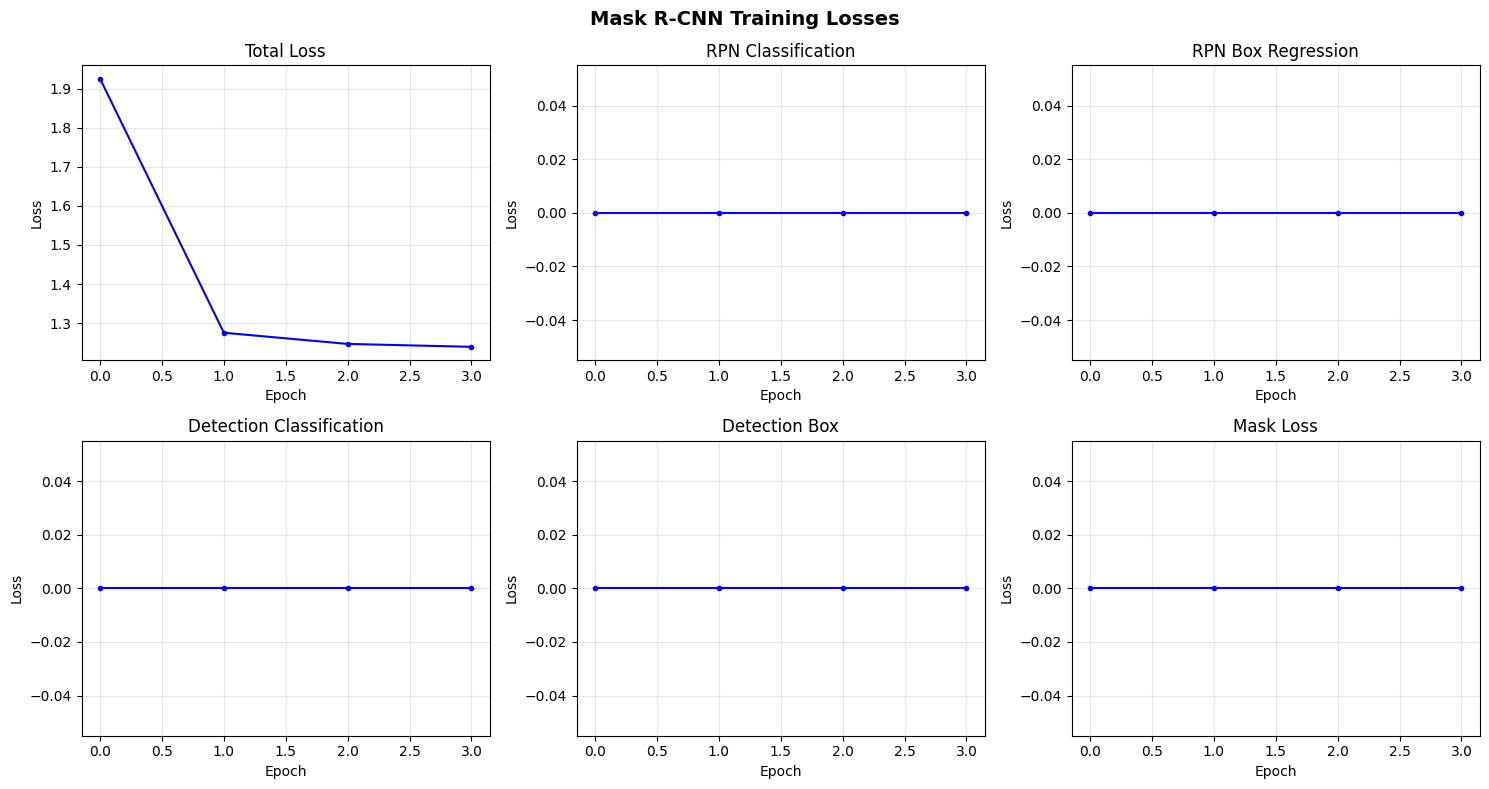

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

loss_keys = ['total', 'rpn_cls', 'rpn_box', 'cls', 'box', 'mask']
titles = ['Total Loss', 'RPN Classification', 'RPN Box Regression',
          'Detection Classification', 'Detection Box', 'Mask Loss']

for ax, key, title in zip(axes.flat, loss_keys, titles):
    vals = [v for v in loss_history[key] if v is not None]
    if vals:
        ax.plot(vals, 'b-o', markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

plt.suptitle('Mask R-CNN Training Losses', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Inference: Detection + Mask Prediction

Let's run the trained model on test images and visualize the results: predicted bounding boxes, class labels, confidence scores, and segmentation masks.


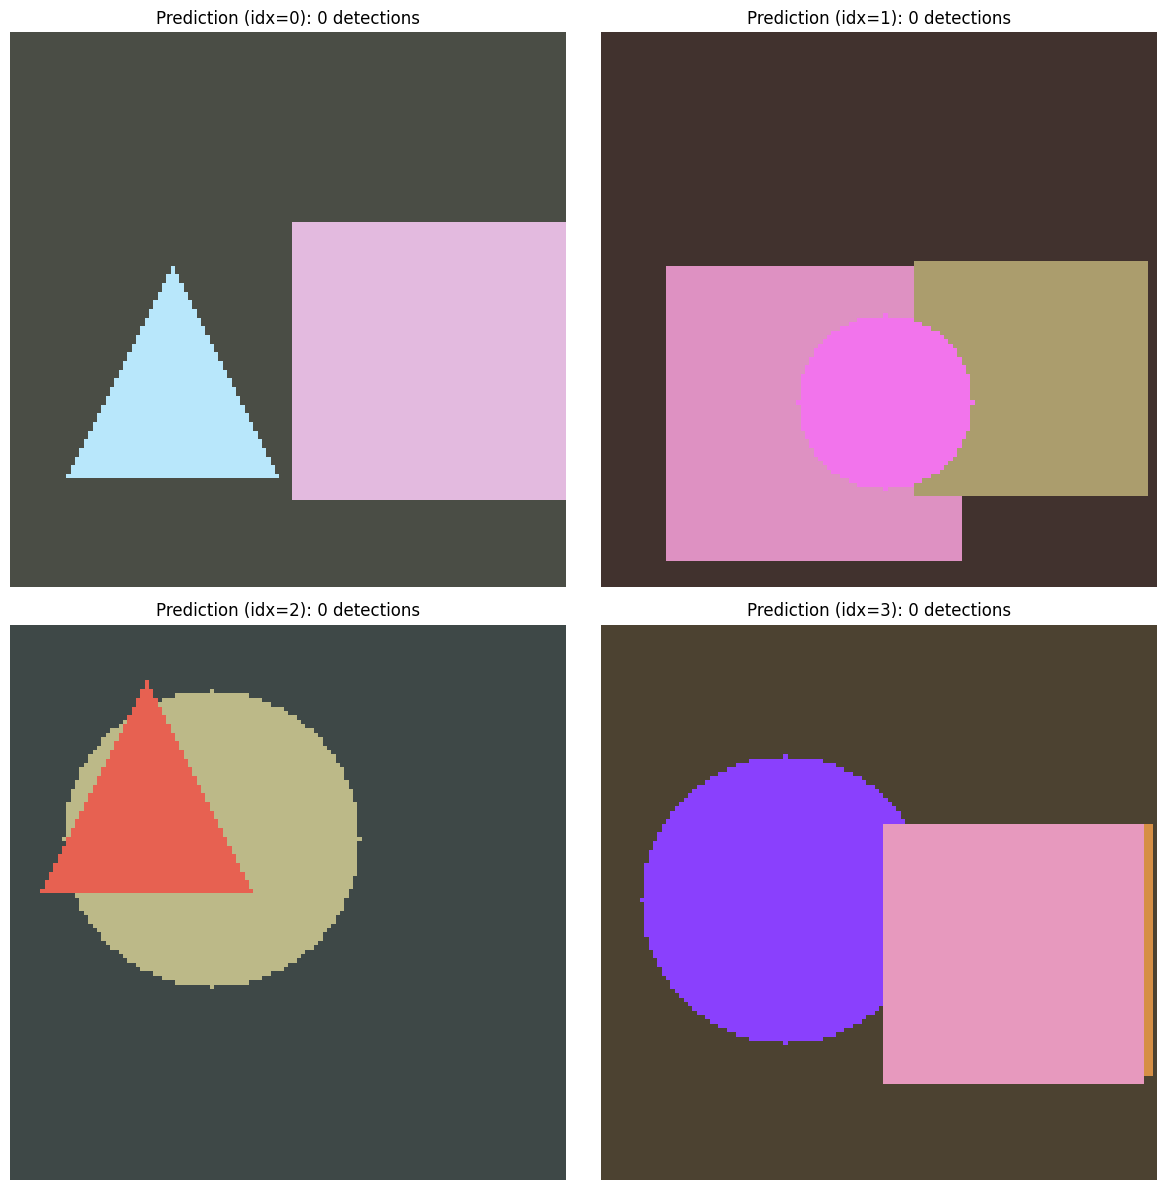

In [13]:
COLORS = ['red', 'lime', 'cyan', 'orange', 'magenta', 'yellow']

def visualize_detections(model, dataset, idx, score_thresh=0.5, ax=None):
    """Run inference and visualize boxes + masks."""
    model.eval()
    with torch.no_grad():
        image = dataset[idx]['image'].to(device)
        results = model(image.unsqueeze(0))[0]

    img = image.cpu().permute(1, 2, 0).numpy()
    boxes = results['boxes'].numpy()
    labels = results['labels'].numpy()
    scores = results['scores'].numpy()
    masks = results['masks'].numpy()

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    ax.imshow(img)

    for i in range(len(boxes)):
        if scores[i] < score_thresh:
            continue
        x1, y1, x2, y2 = boxes[i]
        label = labels[i]
        color = COLORS[label % len(COLORS)]

        # Bounding box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        # Mask overlay
        mask = masks[i]
        colored_mask = np.zeros((*mask.shape, 4))
        rgba = plt.cm.colors.to_rgba(color)
        colored_mask[mask > 0] = [rgba[0], rgba[1], rgba[2], 0.4]
        ax.imshow(colored_mask)

        # Label + score
        ax.text(x1, y1-2, f'{dataset.CLASS_NAMES[label]} ({scores[i]:.2f})',
                color='white', fontsize=7, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8))

    ax.set_title(f'Prediction (idx={idx}): {sum(s >= score_thresh for s in scores)} detections')
    ax.axis('off')
    if ax is None:
        plt.tight_layout()
        plt.show()

# Show 4 test predictions
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    visualize_detections(model, test_ds, i, score_thresh=0.5, ax=ax)
plt.tight_layout()
plt.show()


## 13. Multi-Scale Detection Analysis


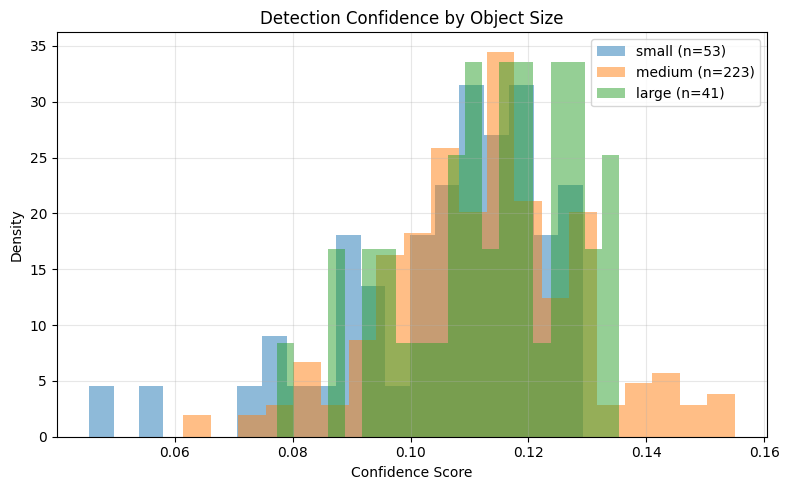

small: 53 detections, avg score=0.105
medium: 223 detections, avg score=0.112
large: 41 detections, avg score=0.114


In [14]:
def analyze_detections_by_scale(model, dataset, num_samples=50):
    """Analyze detection performance by object size."""
    model.eval()
    size_bins = {'small': [], 'medium': [], 'large': []}

    with torch.no_grad():
        for idx in range(min(num_samples, len(dataset))):
            image = dataset[idx]['image'].to(device)
            gt_boxes = dataset[idx]['boxes']
            results = model(image.unsqueeze(0))[0]

            # Match predictions to GT
            if len(results['boxes']) == 0 or len(gt_boxes) == 0:
                continue

            ious = box_iou(results['boxes'], gt_boxes)
            max_iou, matched = ious.max(dim=1)

            for i in range(len(results['boxes'])):
                if max_iou[i] > 0.5:
                    gt_box = gt_boxes[matched[i]]
                    gt_w = (gt_box[2] - gt_box[0]).item()
                    gt_h = (gt_box[3] - gt_box[1]).item()
                    area = gt_w * gt_h
                    score = results['scores'][i].item()

                    if area < 1500:
                        size_bins['small'].append(score)
                    elif area < 4000:
                        size_bins['medium'].append(score)
                    else:
                        size_bins['large'].append(score)

    fig, ax = plt.subplots(figsize=(8, 5))
    for label, scores in size_bins.items():
        if scores:
            ax.hist(scores, bins=20, alpha=0.5, label=f'{label} (n={len(scores)})', density=True)

    ax.set_xlabel('Confidence Score')
    ax.set_ylabel('Density')
    ax.set_title('Detection Confidence by Object Size')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    for label, scores in size_bins.items():
        if scores:
            print(f"{label}: {len(scores)} detections, avg score={np.mean(scores):.3f}")

analyze_detections_by_scale(model, test_ds)


## 14. Mask Quality Evaluation (mAP)


In [15]:
def compute_mask_iou(pred_mask, gt_mask):
    """Compute IoU between two binary masks."""
    intersection = (pred_mask & gt_mask).sum().item()
    union = (pred_mask | gt_mask).sum().item()
    if union == 0:
        return 1.0
    return intersection / union


def compute_ap(recalls, precisions):
    """Compute Average Precision using 11-point interpolation."""
    ap = 0.0
    for t in np.linspace(0, 1, 11):
        mask = recalls >= t
        if mask.any():
            ap += precisions[mask].max()
    return ap / 11.0


def evaluate_map(model, dataset, iou_thresh=0.5, score_thresh=0.3, num_samples=None):
    """Compute mean Average Precision for masks at IoU 0.5."""
    model.eval()
    aps = defaultdict(list)

    n = num_samples or len(dataset)
    with torch.no_grad():
        for idx in range(n):
            image = dataset[idx]['image'].to(device)
            gt_boxes = dataset[idx]['boxes'].numpy()
            gt_labels = dataset[idx]['labels'].numpy()
            gt_masks = dataset[idx]['masks'].numpy()

            results = model(image.unsqueeze(0))[0]
            pred_boxes = results['boxes'].numpy()
            pred_labels = results['labels'].numpy()
            pred_scores = results['scores'].numpy()
            pred_masks = results['masks'].numpy()

            # Filter by score
            valid = pred_scores >= score_thresh
            pred_boxes = pred_boxes[valid]
            pred_labels = pred_labels[valid]
            pred_scores = pred_scores[valid]
            pred_masks = pred_masks[valid]

            # For each class, compute AP
            for c in range(1, dataset.NUM_CLASSES):
                class_name = dataset.CLASS_NAMES[c]
                gt_c = [i for i in range(len(gt_labels)) if gt_labels[i] == c]
                pred_c = [i for i in range(len(pred_labels)) if pred_labels[i] == c]

                if len(gt_c) == 0 and len(pred_c) == 0:
                    continue

                # Sort predictions by score
                pred_c_sorted = sorted(pred_c, key=lambda i: -pred_scores[i])

                tp = []
                fp = []
                gt_matched = set()

                for pi in pred_c_sorted:
                    best_iou = 0
                    best_gt = -1
                    for gi in gt_c:
                        if gi in gt_matched:
                            continue
                        # Box IoU
                        pb = pred_boxes[pi]
                        gb = gt_boxes[gi]
                        ix1 = max(pb[0], gb[0])
                        iy1 = max(pb[1], gb[1])
                        ix2 = min(pb[2], gb[2])
                        iy2 = min(pb[3], gb[3])
                        iw = max(0, ix2 - ix1)
                        ih = max(0, iy2 - iy1)
                        inter = iw * ih
                        pb_a = (pb[2]-pb[0]) * (pb[3]-pb[1])
                        gb_a = (gb[2]-gb[0]) * (gb[3]-gb[1])
                        union = pb_a + gb_a - inter
                        box_iou_val = inter / max(union, 1e-6)

                        if box_iou_val > best_iou:
                            # Also check mask IoU
                            pm = pred_masks[pi]
                            gm = gt_masks[gi]
                            mask_iou = compute_mask_iou(pm, gm)
                            if mask_iou > best_iou:
                                best_iou = mask_iou
                                best_gt = gi

                    if best_iou >= iou_thresh and best_gt >= 0:
                        tp.append(1)
                        fp.append(0)
                        gt_matched.add(best_gt)
                    else:
                        tp.append(0)
                        fp.append(1)

                if len(pred_c_sorted) == 0:
                    continue

                tp_cum = np.cumsum(tp)
                fp_cum = np.cumsum(fp)
                recalls = tp_cum / max(len(gt_c), 1)
                precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-6)

                ap = compute_ap(recalls, precisions)
                aps[class_name].append(ap)

    print("=" * 50)
    print(f"Mask mAP@0.5 Evaluation ({n} samples)")
    print("=" * 50)
    all_aps = []
    for cls, cls_aps in sorted(aps.items()):
        avg_ap = np.mean(cls_aps) if cls_aps else 0.0
        all_aps.append(avg_ap)
        print(f"  {cls:15s}: AP = {avg_ap:.4f} ({len(cls_aps)} images)")

    mean_ap = np.mean(all_aps) if all_aps else 0.0
    print(f"  {'mAP':15s}: {mean_ap:.4f}")
    print("=" * 50)
    return mean_ap

mean_ap = evaluate_map(model, test_ds, iou_thresh=0.5, score_thresh=0.3)


Mask mAP@0.5 Evaluation (50 samples)
  mAP            : 0.0000


## 15. Ground Truth vs Prediction Comparison


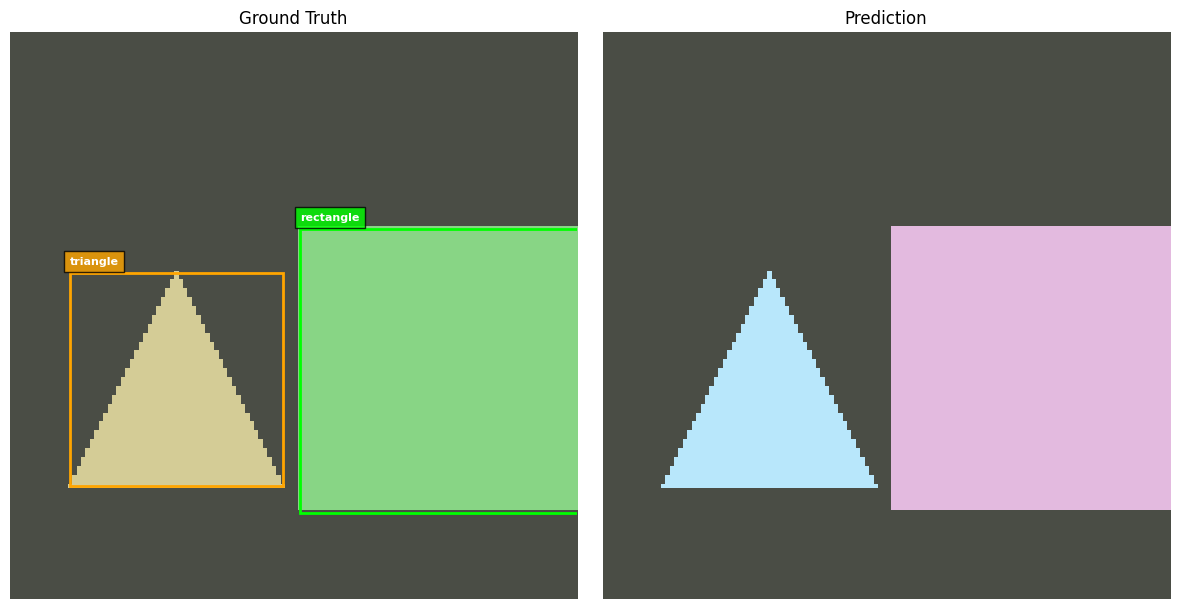

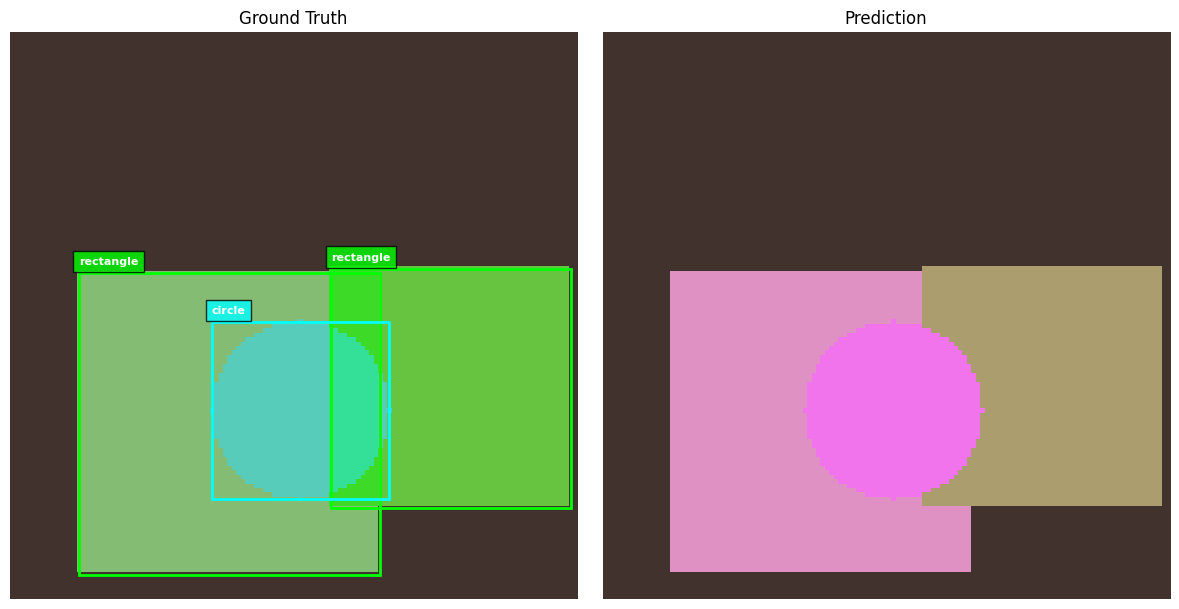

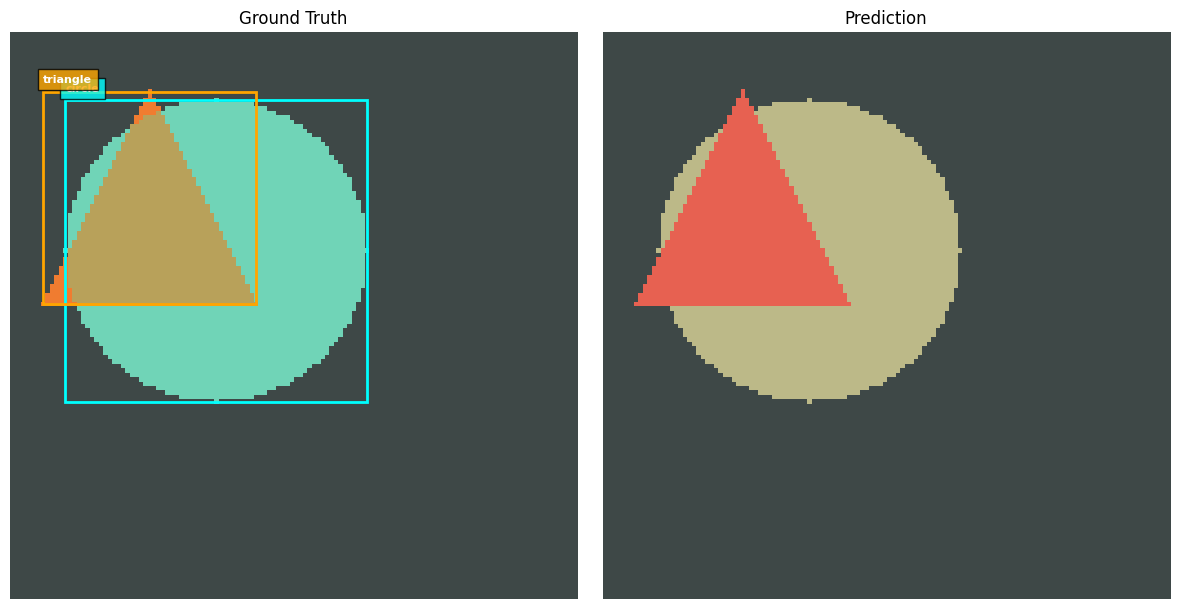

In [16]:
def compare_gt_pred(model, dataset, idx, score_thresh=0.5):
    """Side-by-side comparison of ground truth and prediction."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Ground truth
    visualize_sample(dataset, idx, ax=ax1)
    ax1.set_title('Ground Truth')

    # Prediction
    visualize_detections(model, dataset, idx, score_thresh=score_thresh, ax=ax2)
    ax2.set_title('Prediction')

    plt.tight_layout()
    plt.show()

for i in range(3):
    compare_gt_pred(model, test_ds, i, score_thresh=0.4)


## 16. RoIAlign vs RoIPool: The Alignment Difference

This ablation demonstrates why RoIAlign is critical: RoIPool's quantization introduces misalignment that hurts mask quality.


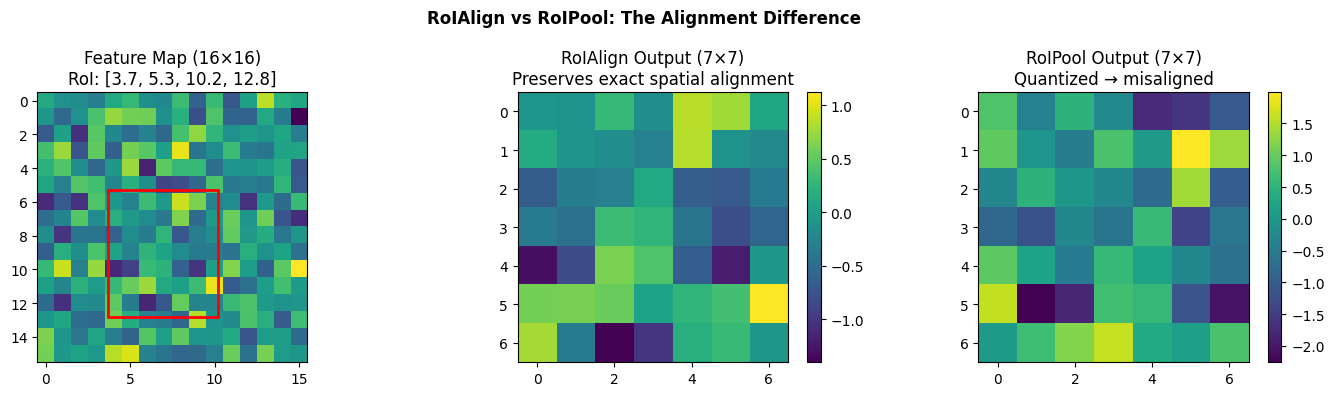


Mean absolute difference: 1.0264
Max absolute difference: 3.1752

This difference may seem small, but for pixel-accurate mask prediction,
it translates to ~3 AP points improvement (paper Table 2c).


In [17]:
def roi_pool_quantized(features, rois, output_size=7, spatial_scale=1.0):
    """RoIPool with quantization (the old method).

    Quantizes RoI coordinates to integer grid positions — this is what
    Mask R-CNN fixes with RoIAlign.
    """
    B, C, H, W = features.shape
    N = rois.shape[0]

    # QUANTIZE coordinates (this is the problem!)
    roi = rois.clone().float()
    roi[:, 1:] = roi[:, 1:] * spatial_scale
    roi[:, 1:] = torch.floor(roi[:, 1:])  # HARSH QUANTIZATION
    roi[:, 1] = roi[:, 1].clamp(0, W - 1)
    roi[:, 2] = roi[:, 2].clamp(0, H - 1)
    roi[:, 3] = roi[:, 3].clamp(1, W)
    roi[:, 4] = roi[:, 4].clamp(1, H)

    output = torch.zeros(N, C, output_size, output_size,
                          device=features.device, dtype=features.dtype)

    for i in range(N):
        batch_idx = int(roi[i, 0].item())
        x1, y1, x2, y2 = (int(roi[i, 1].item()), int(roi[i, 2].item()),
                          int(roi[i, 3].item()), int(roi[i, 4].item()))
        feat = features[batch_idx]
        roi_w = max(x2 - x1, 1)
        roi_h = max(y2 - y1, 1)

        for ph in range(output_size):
            for pw in range(output_size):
                # QUANTIZE bin boundaries
                bx1 = x1 + int(pw * roi_w / output_size)
                by1 = y1 + int(ph * roi_h / output_size)
                bx2 = x1 + int((pw + 1) * roi_w / output_size)
                by2 = y1 + int((ph + 1) * roi_h / output_size)
                bx2 = min(bx2, W)
                by2 = min(by2, H)
                bx1 = min(bx1, W - 1)
                by1 = min(by1, H - 1)
                bx2 = max(bx2, bx1 + 1)
                by2 = max(by2, by1 + 1)
                output[i, :, ph, pw] = feat[:, by1:by2, bx1:bx2].amax(dim=(1, 2))

    return output


# Demonstrate the difference on a single feature map
torch.manual_seed(123)
dummy_feat = torch.randn(1, 4, 16, 16)  # 16x16 feature map
# A RoI with non-integer coordinates
roi = torch.tensor([[0, 3.7, 5.3, 10.2, 12.8]])  # fractional coordinates

align_out = roi_align(dummy_feat, roi, output_size=7, spatial_scale=1.0, sampling_ratio=4)
pool_out = roi_pool_quantized(dummy_feat, roi, output_size=7, spatial_scale=1.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Show feature map
axes[0].imshow(dummy_feat[0, 0].numpy(), cmap='viridis')
axes[0].set_title('Feature Map (16×16)\nRoI: [3.7, 5.3, 10.2, 12.8]')
axes[0].add_patch(patches.Rectangle((3.7, 5.3), 6.5, 7.5,
                                     linewidth=2, edgecolor='red', facecolor='none'))

# RoIAlign output
im1 = axes[1].imshow(align_out[0, 0].numpy(), cmap='viridis')
axes[1].set_title(f'RoIAlign Output (7×7)\nPreserves exact spatial alignment')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# RoIPool output
im2 = axes[2].imshow(pool_out[0, 0].numpy(), cmap='viridis')
axes[2].set_title(f'RoIPool Output (7×7)\nQuantized → misaligned')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle('RoIAlign vs RoIPool: The Alignment Difference', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

diff = (align_out[0, 0] - pool_out[0, 0]).abs()
print(f"\nMean absolute difference: {diff.mean().item():.4f}")
print(f"Max absolute difference: {diff.max().item():.4f}")
print(f"\nThis difference may seem small, but for pixel-accurate mask prediction,")
print(f"it translates to ~3 AP points improvement (paper Table 2c).")


## 17. More Detection Examples


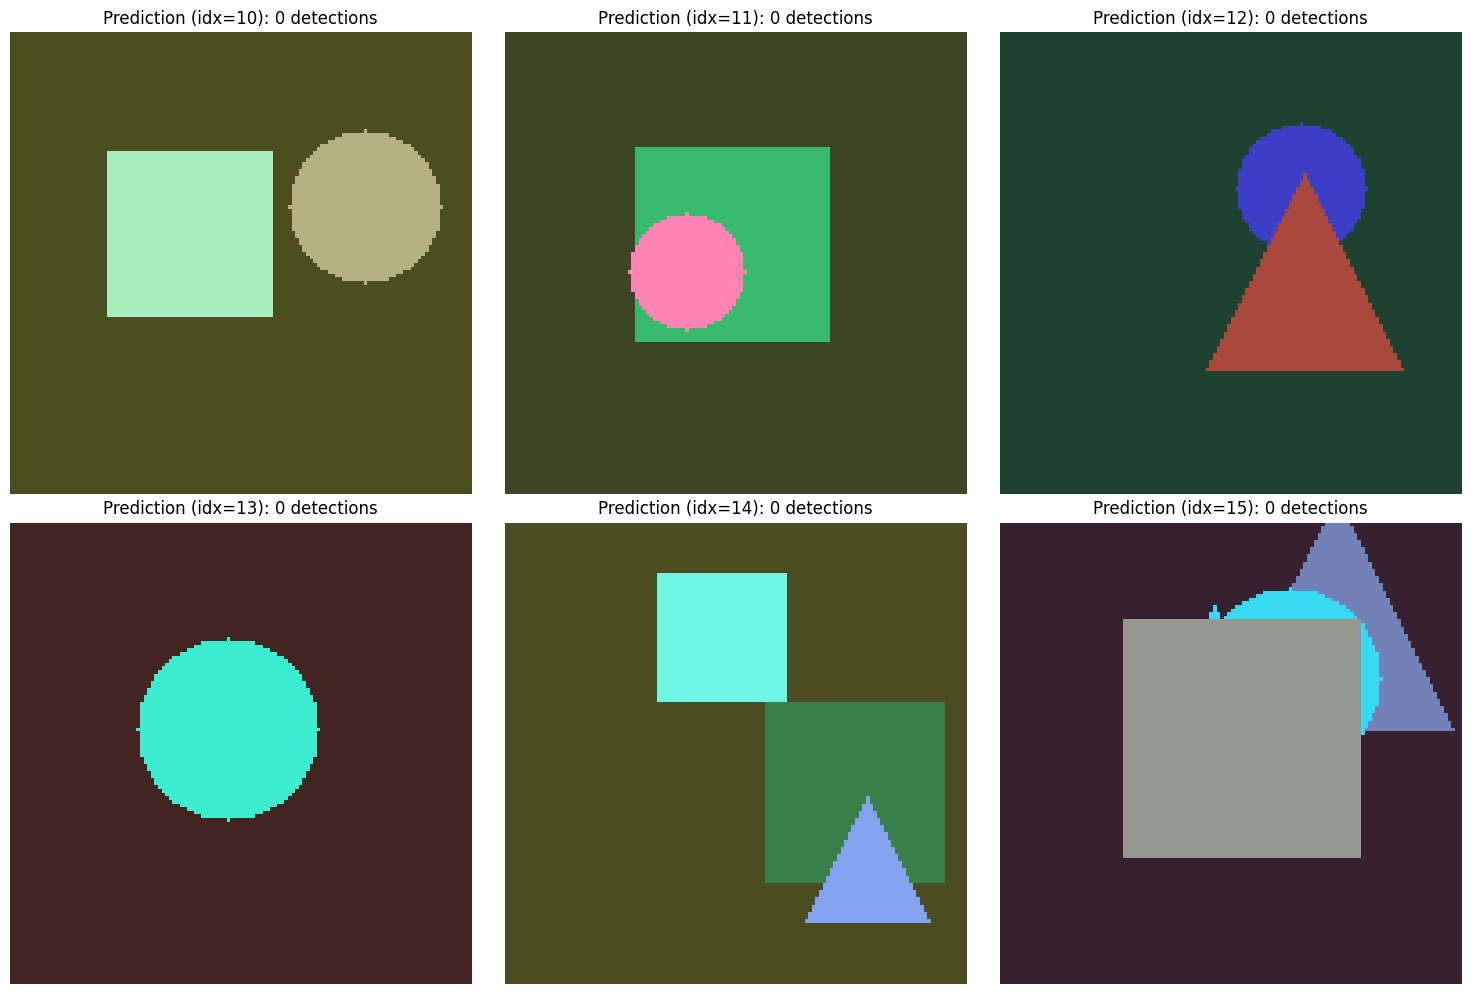


Mask R-CNN Summary
Mask mAP@0.5: 0.0000
Key innovations demonstrated:
  1. Parallel mask prediction branch (small FCN per RoI)
  2. RoIAlign (quantization-free bilinear interpolation)
  3. Decoupled per-class sigmoid masks (not softmax)
  4. Multi-task loss: L = L_cls + L_box + L_mask + L_rpn


In [18]:
# Show more examples with varying number of objects
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    visualize_detections(model, test_ds, i + 10, score_thresh=0.4, ax=ax)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Mask R-CNN Summary")
print("=" * 60)
print(f"Mask mAP@0.5: {mean_ap:.4f}")
print(f"Key innovations demonstrated:")
print(f"  1. Parallel mask prediction branch (small FCN per RoI)")
print(f"  2. RoIAlign (quantization-free bilinear interpolation)")
print(f"  3. Decoupled per-class sigmoid masks (not softmax)")
print(f"  4. Multi-task loss: L = L_cls + L_box + L_mask + L_rpn")
print("=" * 60)


In [19]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
